In [2]:
import pandas as pd
import numpy as np
import os

from sklearn.metrics import (
    roc_auc_score, precision_score, 
    recall_score, f1_score, 
    matthews_corrcoef,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
from utils import *

import mlflow
import mlflow.xgboost

import warnings
import argparse
import logging
from typing import *

import matplotlib.pyplot as plt
import seaborn as sns

from namespaces import DA

In [3]:
logging.basicConfig(level=logging.WARN)
logger = logging.getLogger(__name__)
warnings.filterwarnings("ignore")

In [4]:
os.chdir('/home/mai/notebooks/final_thesis/')
os.getcwd()

'/home/mai/notebooks/final_thesis'

In [6]:
# search for the best run
experiment_name = 'xgb_optuna_tuning'
metric_name = ['ap', 'mcc']

exp = mlflow.get_experiment_by_name(experiment_name)
runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string="params.feat_augment = 'True'",
    order_by=[
        f"metrics.{metric_name[0]} DESC",
    ],
    max_results=1
)

best_run = runs.iloc[0]
best_run_id = best_run.run_id

print("Best run:", best_run_id)
print("Best metric - AP:", best_run[f"metrics.{metric_name[0]}"])

Best run: 944a58b8183c4f72abd9c5c699050c57
Best metric - AP: 0.36461230168156517


In [7]:
# load best model
model = mlflow.xgboost.load_model(f"runs:/{best_run_id}/model")

In [12]:
# feature importance analysis
importance = model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'feature': list(importance.keys()),
    'importance': list(importance.values())
}).sort_values(by='importance', ascending=False)

In [22]:
# assign feature names
# default 17 features do not have names
default_features = [f'var_{i}' for i in range(17)]
# additional features
additional_features = ['out_degree', 'in_degree', 'degree_ratio', 'recency', 'burst_ratio', 'mean_dts', 'std_dts']

feature_names = default_features + additional_features
feature_names = {str(i): name for i, name in enumerate(feature_names)}
importance_df['feature_name'] = importance_df['feature'].map(feature_names)

In [23]:
importance_df.dtypes

feature          object
importance      float64
feature_name     object
dtype: object

In [24]:
importance_df.head(10)

,feature,importance,feature_name
22,22,3444.993652,mean_dts
18,18,2420.028076,in_degree
21,21,1232.785278,burst_ratio
20,20,884.458557,recency
23,23,805.884460,std_dts
17,17,405.164795,out_degree
2,2,392.226074,var_2
19,19,248.891602,degree_ratio
0,0,187.847382,var_0
6,6,169.454300,var_6


Text(0.5, 0, 'Importance')

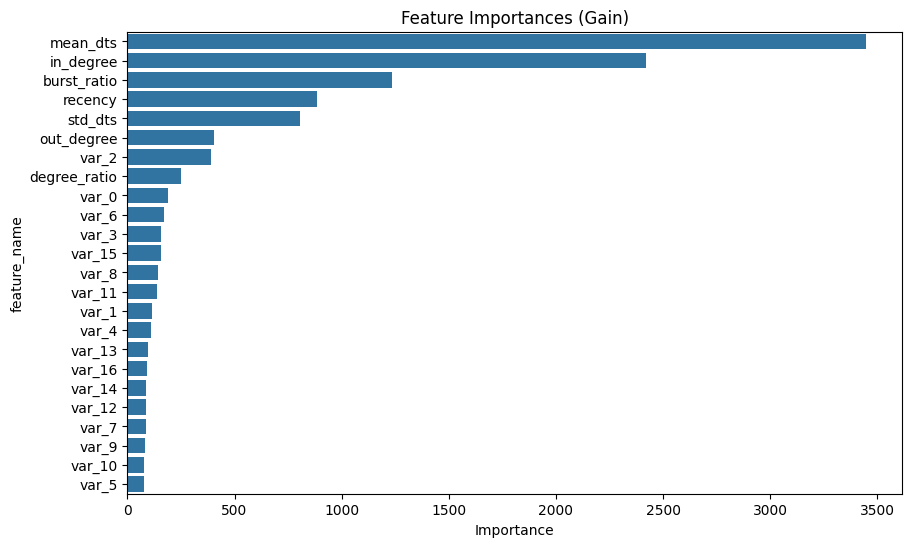

In [25]:
# visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature_name', data=importance_df)
plt.title('Feature Importances (Gain)')
plt.xlabel('Importance')

#### Old

In [26]:
def load_data(data_path, feat_augment=True):
    data = np.load(os.path.join(data_path, 'dgraphfin_processed.npz'))
    # train
    X_train = pd.DataFrame(data['x_train'])
    y_train = pd.DataFrame(data['y_train'])
    # val
    X_val = pd.DataFrame(data['x_val'])
    y_val = pd.DataFrame(data['y_val'])
    # test
    X_test = pd.DataFrame(data['x_test'])
    y_test = pd.DataFrame(data['y_test'])

    if not feat_augment:
        X_train = X_train.iloc[:, :17]
        X_val = X_val.iloc[:, :17]
        X_test = X_test.iloc[:, :17]
    return X_train, X_val, X_test, y_train, y_val, y_test

In [31]:
X_train, X_val, X_test, y_train, y_val, y_test = load_data(DA.paths.output_data_ml, feat_augment=True)

X_train.columns = feature_names.values()
y_train.columns = ['y']

In [32]:
df_train = pd.concat([X_train, y_train], axis=1)

In [33]:
df_train.head()

,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,...,var_15,var_16,out_degree,in_degree,degree_ratio,recency,burst_ratio,mean_dts,std_dts,y
0,1.0,5.0,0.375,0.30,0.800000,0.5,0.321,0.021,0.305,0.950156,...,0.026667,0.400000,-0.118323,-0.509150,-0.126990,-0.520594,1.098802,-1.232473,-0.654639,1
1,0.0,6.0,-1.000,-1.00,-1.000000,-1.0,-1.000,-1.000,-1.000,-1.000000,...,-1.000000,-1.000000,-0.851297,3.072484,-0.645313,-0.520592,0.673479,-0.883745,0.366727,1
2,1.0,6.0,1.020,0.93,0.911765,0.6,1.356,0.103,1.327,0.978614,...,0.004902,0.166667,-0.118323,-1.225477,0.391333,1.910005,-1.453140,-1.415108,-0.654639,1
3,1.0,2.0,-1.000,-1.00,-1.000000,-1.0,-1.000,-1.000,-1.000,-1.000000,...,-1.000000,-1.000000,5.745467,-1.225477,8.684505,1.910005,-1.453140,-1.415108,-0.654639,1
4,1.0,5.0,-1.000,-1.00,-1.000000,-1.0,-1.000,-1.000,-1.000,-1.000000,...,-1.000000,-1.000000,-0.118323,-1.225477,0.391333,1.910005,-1.453140,-1.415108,-0.654639,1


In [49]:
df_train['var_2'].describe()

count    857899.000000
mean          0.545364
std           1.941448
min          -1.000000
25%          -1.000000
50%           0.365000
75%           1.150000
max         111.815000
Name: var_2, dtype: float64

In [48]:
df_train['mean_dts'].describe()

count    857899.000000
mean          0.000055
std           1.000234
min          -1.415108
25%          -1.057778
50%           0.141262
75%           0.800337
max           1.721454
Name: mean_dts, dtype: float64

<Axes: >

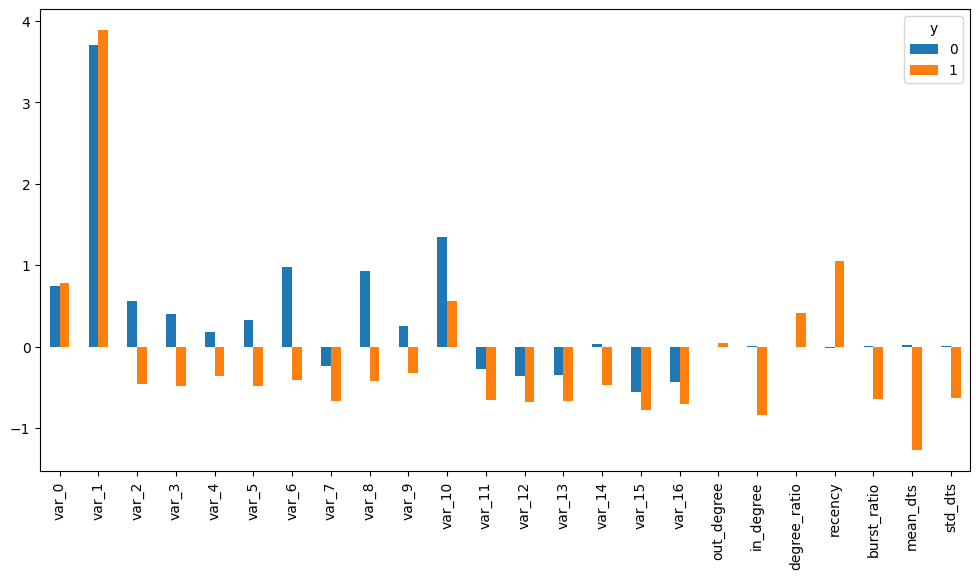

In [47]:
df_train.groupby('y')[list(feature_names.values())].mean().T.plot(kind='bar', figsize=(12, 6))